#  Musical Attribute analysis

**Sources & Description**

Title: Spotify Tracks Attributes and Popularity (Main Dataset)

Description : This dataset contains song data from Spotify, including audio features and popularity scores. Key variables include danceability,explicitly , energy, acousticness, instrumentalness, valence along with track and artist information.

Source: https://www.kaggle.com/datasets/sanjanchaudhari/spotify-dataset


(second dataset)

Title: Spotify dataset

Description: This dataset contains song data from spotify, This includes Artist, Track, Album, album_type, Danceability, energy ,loudness, speechiness, acousticness, instrumentalness.

Source: https://www.kaggle.com/datasets/melissamonfared/spotify-tracks-attributes-and-popularity/data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
dataset = pd.read_csv(r"C:\Users\ava\Downloads\dataset.csv")
cleaned_dataset = pd.read_csv(r"C:\Users\ava\Downloads\cleaned_dataset.csv")

In [5]:
dataset.head(5)

,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
cleaned_dataset.head(5)

,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,True,True,6.306347e+07,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,True,True,4.346636e+08,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,True,True,6.172597e+08,9.942693,Youtube


**Level one Cleaning**

In [8]:
spotify_clean = dataset.copy()

# Remove duplicate songs
spotify_clean = spotify_clean.drop_duplicates(subset=['track_id'])

# Remove rows missing important information
spotify_clean = spotify_clean.dropna(
    subset=['track_id', 'artists', 'track_name', 'popularity']
)

# Clean text formatting
spotify_clean['artists'] = spotify_clean['artists'].str.strip()
spotify_clean['track_name'] = spotify_clean['track_name'].str.strip()
spotify_clean['album_name'] = spotify_clean['album_name'].str.strip()

spotify_clean.shape

(89740, 21)

This first level of cleaning focused on removing duplicate tracks, handling missing values, and fixing formats across datasets

**Level two Cleaning**

In [11]:
# Remove impossible or unrealistic values
spotify_clean = spotify_clean[
    (spotify_clean['duration_ms'] > 0) &
    (spotify_clean['tempo'] > 0) &
    (spotify_clean['popularity'] > 0)
]

# Create duration in minutes
spotify_clean['duration_min'] = spotify_clean['duration_ms'] / 60000

# Selecting useful columns
audio_features = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_min'
]

spotify_clean[audio_features].describe()

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000,80140.000000
mean,37.102833,0.563919,0.641885,-8.425115,0.089156,0.320941,0.178080,0.219722,0.468730,122.711609,3.850197
std,18.136135,0.174082,0.253397,5.105461,0.116793,0.334367,0.326689,0.198034,0.261506,29.627699,1.895940
min,1.000000,0.051300,0.000020,-46.591000,0.022100,0.000000,0.000000,0.009250,0.000000,30.322000,0.404433
25%,22.000000,0.453000,0.467000,-10.255000,0.036000,0.015000,0.000000,0.098500,0.250000,99.968000,2.902679
50%,37.000000,0.576000,0.683000,-7.186000,0.049200,0.181000,0.000073,0.133000,0.455000,122.538500,3.591642
75%,50.000000,0.692000,0.858000,-5.104000,0.087300,0.610000,0.119000,0.283000,0.679250,140.977000,4.449333
max,100.000000,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,87.288250


This level of cleaning focused on improving the quality of the data by removing unrealistic value

In [13]:
spotify_clean['popularity_group'] = pd.qcut(
    spotify_clean['popularity'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
    duplicates='drop'
)

# Create a popular/not popular variable using the top 25%
cutoff = spotify_clean['popularity'].quantile(0.75)

spotify_clean['popular_song'] = spotify_clean['popularity'] >= cutoff

# Check the distribution
spotify_clean['popularity_group'].value_counts()

popularity_group
Medium-Low     20734
Low            20167
High           19932
Medium-High    19307
Name: count, dtype: int64

In [14]:
spotify_clean['popular_song'].value_counts()

popular_song
False    58947
True     21193
Name: count, dtype: int64

## Research question: What spotify features are related to song popularity?

## EDA

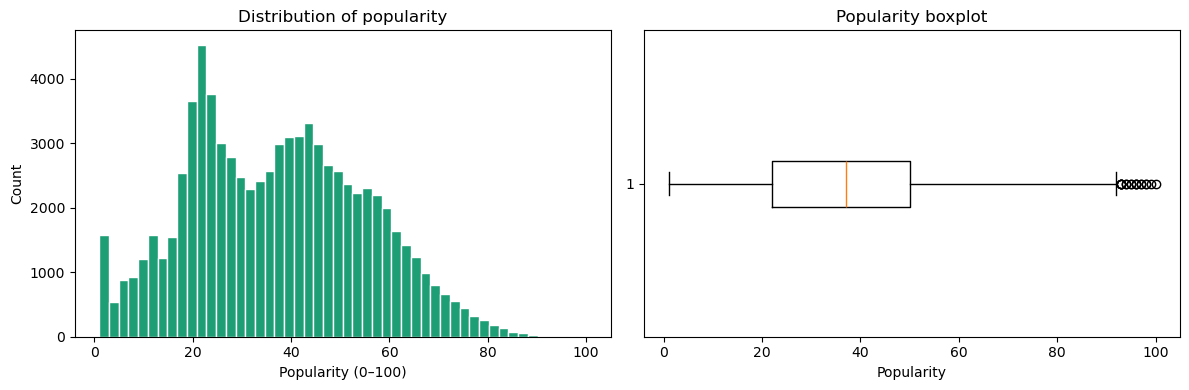

count    80140.000000
mean        37.102833
std         18.136135
min          1.000000
25%         22.000000
50%         37.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

Songs with popularity == 0: 0
Songs with popularity >= 80: 626 (truly popular)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(spotify_clean['popularity'], bins=50, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribution of popularity')
axes[0].set_xlabel('Popularity (0–100)')
axes[0].set_ylabel('Count')

axes[1].boxplot(spotify_clean['popularity'], vert=False)
axes[1].set_title('Popularity boxplot')
axes[1].set_xlabel('Popularity')

plt.tight_layout()
plt.show()

print(spotify_clean['popularity'].describe())
print(f"\nSongs with popularity == 0: {(spotify_clean['popularity'] == 0).sum():,}")
print(f"Songs with popularity >= 80: {(spotify_clean['popularity'] >= 80).sum():,} (truly popular)")

Before examining the relationship between the variable popularity and the audio features, we plotted a histogram for each of the ten audio features to better understand their individual distributions. This step helps identify skewness, outliers, and non-normality, which can affect which statistical methods are most appropriate for the analysis.

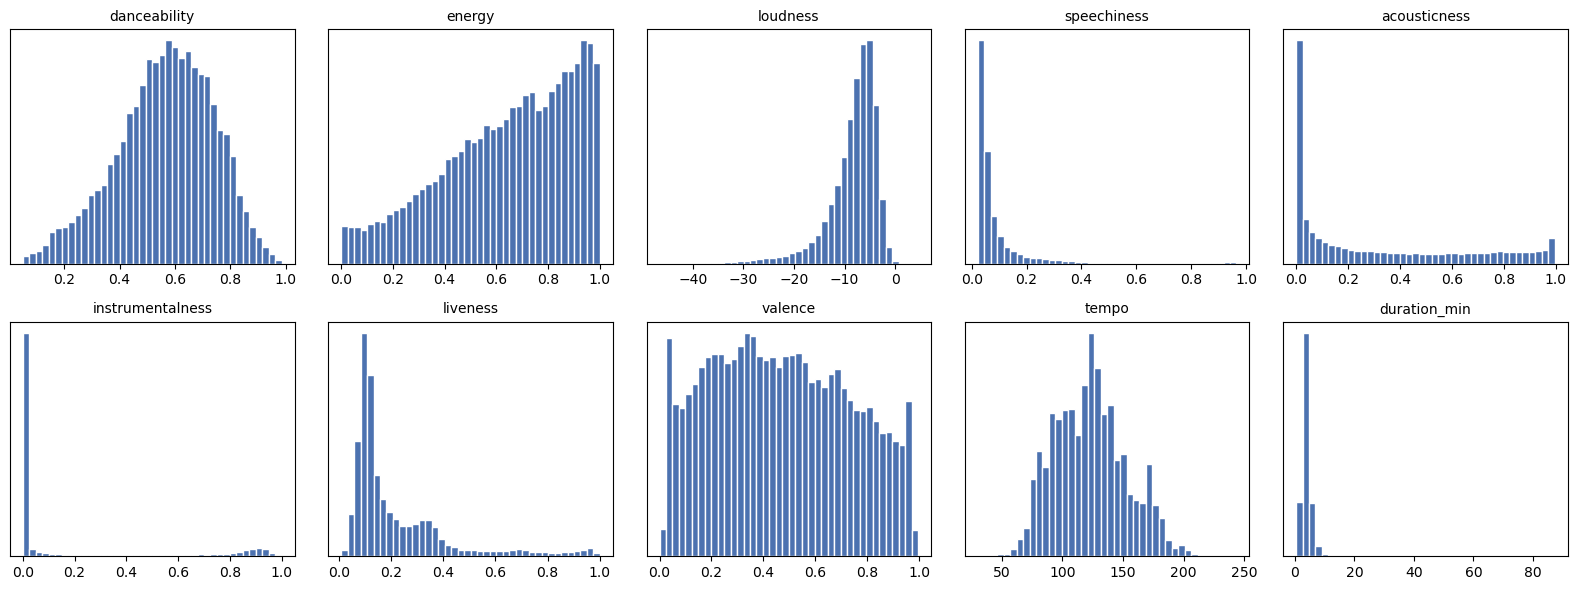

In [19]:
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence',
            'tempo', 'duration_min']

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, feat in zip(axes.flat, features):
    ax.hist(spotify_clean[feat], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.set_yticks([])
plt.tight_layout()
plt.show()

As the plots show, danceability and tempo are approximately bell-shaped, making them well suited for standard linear methods. Energy and loudness are left-skewed, with most songs concentrated at the high-energy and louder ends of their ranges, while speechiness and liveness are right-skewed, reflecting that the dataset consists primarily of studio-recorded music rather than spoken-word or live recordings. Valence is the most uniformly distributed feature, spanning the full 0–1 range relatively evenly. Furthermore, acousticness and instrumentalness show a strongly bimodal pattern.

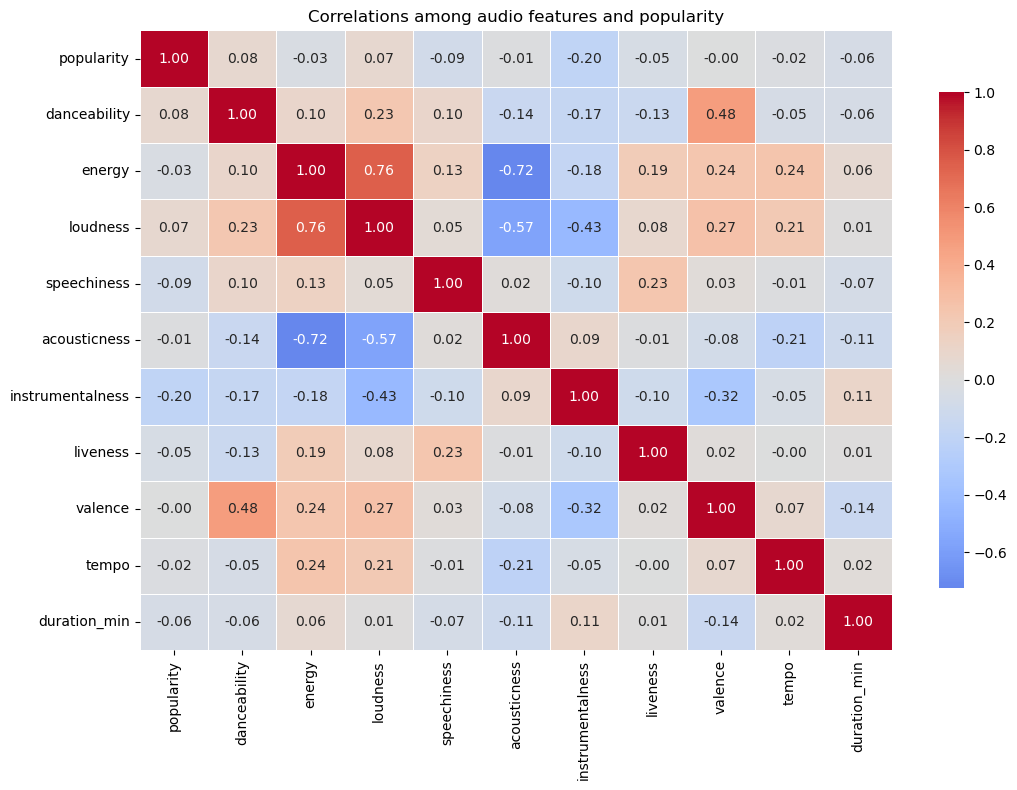

Correlation of each feature with popularity (sorted by magnitude):
                       r  r_squared
instrumentalness -0.1958     0.0383
speechiness      -0.0850     0.0072
danceability      0.0753     0.0057
loudness          0.0743     0.0055
duration_min     -0.0606     0.0037
liveness         -0.0505     0.0026
energy           -0.0342     0.0012
tempo            -0.0192     0.0004
acousticness     -0.0069     0.0000
valence          -0.0017     0.0000


In [21]:
numeric_cols = ['popularity'] + features
corr_matrix = spotify_clean[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Correlations among audio features and popularity')
plt.tight_layout()
plt.show()

# The single most important row: how each feature correlates with popularity
print("Correlation of each feature with popularity (sorted by magnitude):")
pop_corr = corr_matrix['popularity'].drop('popularity').sort_values(
    key=lambda s: s.abs(), ascending=False
)
print(pop_corr.to_frame('r').assign(r_squared=lambda d: d['r']**2).round(4))

The Pearson correlation matrix was visualized using a Seaborn heatmap to measure pairwise linear relationships between all numerical audio features and popularity. The results show that no audio feature has a strong relationship with popularity. The highest correlation is instrumentalness (r = –0.20), indicating a weak tendency for instrumental tracks to be slightly less popular, and explaining only about 4% of the variance (r² ≈ 0.04). Among all features, danceability (0.08) and loudness (0.07) show the strongest positive correlations with popularity, though both are still weak. All other features also display weak positive or negative correlations with popularity, suggesting that audio features alone do not meaningfully explain song popularity.

In [26]:
feature_comparison = spotify_clean.groupby('popular_song')[features].median()
print(feature_comparison.T)

popular_song           False       True 
danceability        0.571000    0.591000
energy              0.692000    0.661000
loudness           -7.325000   -6.803000
speechiness         0.050100    0.047000
acousticness        0.184000    0.175000
instrumentalness    0.000122    0.000021
liveness            0.138000    0.123000
valence             0.466000    0.433000
tempo             123.023000  121.000000
duration_min        3.633333    3.503117


Based on the mean comparison and the heatmap results, we can see that the features most associated with song popularity are loudness and danceability. Popular songs also tend to have higher energy and lower acousticness, suggesting that louder, more energetic, and danceable songs are generally more likely to become popular.

In [30]:
print(spotify_clean.groupby('explicit')['popularity'].agg(['count', 'mean', 'median', 'std']))
print()
g1 = spotify_clean.loc[spotify_clean['explicit'] == True, 'popularity']
g0 = spotify_clean.loc[spotify_clean['explicit'] == False, 'popularity']

pooled_sd = np.sqrt(((g1.std() ** 2) + (g0.std() ** 2)) / 2)
cohens_d = (g1.mean() - g0.mean()) / pooled_sd

print(f"Cohen's d (explicit vs non-explicit): {cohens_d:.3f}")

          count       mean  median        std
explicit                                     
False     73207  36.734930    37.0  17.940171
True       6933  40.987596    41.0  19.674951

Cohen's d (explicit vs non-explicit): 0.226


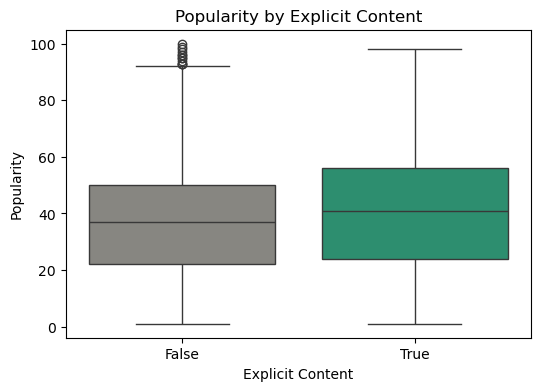

In [33]:
# Visualization
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    x='explicit',
    y='popularity',
    data=spotify_clean,
    hue='explicit',
    palette=['#888780', '#1D9E75'],
    legend=False
)

ax.set_title('Popularity by Explicit Content')
ax.set_xlabel('Explicit Content')
ax.set_ylabel('Popularity')

plt.show()

We compared popularity between explicit and non-explicit songs using summary statistics, a boxplot, and Cohen’s d to measure effect size. The results show that explicit songs have a slightly higher median popularity (≈41) than non-explicit songs (≈37), with a small upward shift in their distribution, but the two groups overlap heavily in range and shape. Cohen’s d = 0.226 indicates a small effect (around 0.2 standard deviations), meaning the difference is real but weak in practical terms. This method is more appropriate than a t-test because the dataset is very large (over 80,000 songs), where even tiny differences would almost always appear statistically significant (very small p-values), making significance testing less meaningful. In contrast, Cohen’s d focuses on the size of the difference rather than whether it is merely detectable, providing a clearer interpretation of practical importance. Overall, explicit content is associated with a slight increase in average popularity, but it is not a strong predictor of how popular a song will be.

In [36]:
genre_pop = spotify_clean.groupby('track_genre')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print("Top 10 most popular genres:")
print(genre_pop.head(10).round(2))
print("\nBottom 10 genres:")
print(genre_pop.tail(10).round(2))
print(f"\nGap between top and bottom genre means: "
      f"{genre_pop['mean'].max() - genre_pop['mean'].min():.1f} popularity points")
print(f"(Compare this to the audio-feature effects — the genre gap is much larger.)")

Top 10 most popular genres:
              mean  count
track_genre              
k-pop        59.68    912
pop-film     59.24    813
metal        57.92    226
latino       57.58    358
soul         57.22    207
edm          57.04    492
electro      56.99    359
pop          56.47    309
chill        55.93    934
house        55.69    121

Bottom 10 genres:
                 mean  count
track_genre                 
breakbeat       20.21    995
tango           20.15    985
honky-tonk      16.41    981
idm             15.74    976
kids            15.20    958
grindcore       14.57    982
chicago-house   12.38    994
detroit-techno  11.14    955
romance          9.15    348
iranian          6.46    340

Gap between top and bottom genre means: 53.2 popularity points
(Compare this to the audio-feature effects — the genre gap is much larger.)


In [37]:
# Standardize features so coefficients are comparable across different scales
from sklearn.preprocessing import StandardScaler

reg_features = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_min']

X = spotify_clean[reg_features].copy()
X['explicit'] = spotify_clean['explicit'].astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled = sm.add_constant(X_scaled)
y = spotify_clean['popularity']

model = sm.OLS(y, X_scaled).fit()
print(model.summary().tables[1])
print(f"\nR-squared: {model.rsquared:.4f}")
print(f"(This means audio features + explicit jointly explain "
      f"{model.rsquared * 100:.1f}% of the variation in popularity.)")

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               37.1028      0.062    601.778      0.000      36.982      37.224
danceability         1.4871      0.075     19.713      0.000       1.339       1.635
energy              -1.6324      0.127    -12.885      0.000      -1.881      -1.384
loudness             0.9315      0.111      8.394      0.000       0.714       1.149
speechiness         -2.2790      0.070    -32.736      0.000      -2.415      -2.143
acousticness        -0.3811      0.095     -4.004      0.000      -0.568      -0.195
instrumentalness    -3.7885      0.075    -50.610      0.000      -3.935      -3.642
liveness            -0.3562      0.067     -5.347      0.000      -0.487      -0.226
valence             -1.8775      0.077    -24.243      0.000      -2.029      -1.726
tempo               -0.1794      0.064     -2.787      0.005     

We fitted a multivariable linear regression model to predict popularity from all audio features and the explicit flag in order to estimate each feature’s unique contribution while controlling for the fact that features are correlated with each other (for example, energy and loudness are strongly related with r ≈ 0.76). Unlike simple correlations, which measure the relationship between one feature and popularity in isolation, regression coefficients show how much a feature contributes to popularity holding all other variables constant, making it the appropriate method for identifying the most important predictors. The model explains only R² = 0.074 of the variance in popularity, meaning audio features together account for just 7.4% of why songs differ in popularity, with the remaining 92.6% driven by external factors.



## Limitations

> One issue is with how Spotify calculates popularity. The popularity score is not something we can fully control or understand because Spotify generates it internally based on streaming activity at a specific point in time. This means a song that was huge a few years ago might have a low score now just because people stopped listening recently. So the popularity column does not really capture whether a song was historically successful, just how it was doing when the data was pulled.

> The second issue is that our two datasets did not line up very well. Dataset.csv had 114,000 songs and cleaned_dataset.csv had around 20,000, but when we tried to match them on Artist and Track name, most songs did not have a match in both files. That meant the streaming data like Views, Likes, and Stream only filled in for a small portion of the combined dataset, leaving a lot of missing values.

> Lastly, just because two things are correlated does not mean one causes the other. Loudness and danceability had the strongest relationships with popularity in our results, but that does not mean a louder or more danceable song will automatically become popular. Things like how big the artist already is, whether the song gets added to major playlists, or how it was marketed probably matter just as much, and none of that is captured in our data.ata.

## Conclusion

> This analysis set out to find which Spotify audio features are most related to song popularity. What we found is that no single audio feature has a strong relationship with popularity, and even combining all of them together only explained about 7.4% of the variation. Genre turned out to be a much stronger predictor than any audio feature we tested. Overall this suggests that what makes a song popular on Spotify has more to do with external factors like artist recognition, genre, and marketing than with how the song actually sounds.